# Smart Device Usage Data Analysis

# Introduction

This study is an analysis of how people are already using their smart devices and the opportunities for growth for the Bellabeat Leaf Product that it reveals.

The Bellabeat Company is a high-tech company that manufactures health-focused smart products for women. It was founded in 2013 by Urska Srsen and Sando Mur. 

The Bellabeat Leaf Product connects to the Bellabeat app to track Activity, Sleep and Stress which are the focus of this analysis.

The data source for this analysis is the Fitbit Fitness Tracker Data from 30 fitbit users. This is a public dataset on Kaggle.

# Objective

This study aims to upgrade Bellabeat company to a larger player on the global smart market.

The goal is to get insights from analysis to help guide marketing strategy for the company.

Datasets about users activity, sleep, calories, weight, steps, heartrate and intensities are used in this analysis.

**Assumption**: Calories in dataframes refers to energy burnt or released and not calories taken in.

# Load Package

In [1]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


# Load and save dataframe 

Here, I will save the dataframes I will be using for this analysis.

In [2]:
activity <- read.csv("/kaggle/input/focus-files-from-the-fitbit-fitness-tracker-data/dailyActivity_merged.csv")
sleep <- read.csv("/kaggle/input/focus-files-from-the-fitbit-fitness-tracker-data/sleepDay_merged.csv")
weight <- read.csv("/kaggle/input/focus-files-from-the-fitbit-fitness-tracker-data/weightLogInfo_merged.csv")
heartrate <- read.csv("/kaggle/input/focus-files-from-the-fitbit-fitness-tracker-data/heartrate_seconds_merged.csv")
dailyCalories <- read.csv("/kaggle/input/focus-files-from-the-fitbit-fitness-tracker-data/dailyCalories_merged.csv")
hourlyCalories <- read.csv("/kaggle/input/focus-files-from-the-fitbit-fitness-tracker-data/hourlyCalories_merged.csv")
dailyIntensities <- read.csv("/kaggle/input/focus-files-from-the-fitbit-fitness-tracker-data/dailyIntensities_merged.csv")
hourlyIntensities <- read.csv("/kaggle/input/focus-files-from-the-fitbit-fitness-tracker-data/hourlyIntensities_merged.csv")
dailySteps <- read.csv("/kaggle/input/focus-files-from-the-fitbit-fitness-tracker-data/dailySteps_merged.csv")
hourlySteps <- read.csv ("/kaggle/input/focus-files-from-the-fitbit-fitness-tracker-data/hourlySteps_merged.csv")
minuteSteps <- read.csv ("/kaggle/input/focus-files-from-the-fitbit-fitness-tracker-data/minuteStepsNarrow_merged.csv")
                         


# Explore Key Tables

# Preview The Data 

In [3]:
head(activity)
head(sleep)
head(weight)
head(heartrate)
head(dailyCalories)
head(hourlyCalories)
head(dailyIntensities)
head(hourlyIntensities)
head(dailySteps)
head(hourlySteps)
head(minuteSteps)


,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
,<dbl>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>
1,1503960366,4/12/2016,13162,8.50,8.50,0,1.88,0.55,6.06,0,25,13,328,728,1985
2,1503960366,4/13/2016,10735,6.97,6.97,0,1.57,0.69,4.71,0,21,19,217,776,1797
3,1503960366,4/14/2016,10460,6.74,6.74,0,2.44,0.40,3.91,0,30,11,181,1218,1776
4,1503960366,4/15/2016,9762,6.28,6.28,0,2.14,1.26,2.83,0,29,34,209,726,1745
5,1503960366,4/16/2016,12669,8.16,8.16,0,2.71,0.41,5.04,0,36,10,221,773,1863
6,1503960366,4/17/2016,9705,6.48,6.48,0,3.19,0.78,2.51,0,38,20,164,539,1728


,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
,<dbl>,<chr>,<int>,<int>,<int>
1,1503960366,4/12/2016 12:00:00 AM,1,327,346
2,1503960366,4/13/2016 12:00:00 AM,2,384,407
3,1503960366,4/15/2016 12:00:00 AM,1,412,442
4,1503960366,4/16/2016 12:00:00 AM,2,340,367
5,1503960366,4/17/2016 12:00:00 AM,1,700,712
6,1503960366,4/19/2016 12:00:00 AM,1,304,320


,Id,Date,WeightKg,WeightPounds,Fat,BMI,IsManualReport,LogId
,<dbl>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<chr>,<dbl>
1,1503960366,5/2/2016 11:59:59 PM,52.6,115.9631,22,22.65,True,1.462234e+12
2,1503960366,5/3/2016 11:59:59 PM,52.6,115.9631,NA,22.65,True,1.462320e+12
3,1927972279,4/13/2016 1:08:52 AM,133.5,294.3171,NA,47.54,False,1.460510e+12
4,2873212765,4/21/2016 11:59:59 PM,56.7,125.0021,NA,21.45,True,1.461283e+12
5,2873212765,5/12/2016 11:59:59 PM,57.3,126.3249,NA,21.69,True,1.463098e+12
6,4319703577,4/17/2016 11:59:59 PM,72.4,159.6147,25,27.45,True,1.460938e+12


,Id,Time,Value
,<dbl>,<chr>,<int>
1,2022484408,4/12/2016 7:21:00 AM,97
2,2022484408,4/12/2016 7:21:05 AM,102
3,2022484408,4/12/2016 7:21:10 AM,105
4,2022484408,4/12/2016 7:21:20 AM,103
5,2022484408,4/12/2016 7:21:25 AM,101
6,2022484408,4/12/2016 7:22:05 AM,95


,Id,ActivityDay,Calories
,<dbl>,<chr>,<int>
1,1503960366,4/12/2016,1985
2,1503960366,4/13/2016,1797
3,1503960366,4/14/2016,1776
4,1503960366,4/15/2016,1745
5,1503960366,4/16/2016,1863
6,1503960366,4/17/2016,1728


...

,Id,ActivityDay,SedentaryMinutes,LightlyActiveMinutes,FairlyActiveMinutes,VeryActiveMinutes,SedentaryActiveDistance,LightActiveDistance,ModeratelyActiveDistance,VeryActiveDistance
,<dbl>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
1,1503960366,4/12/2016,728,328,13,25,0,6.06,0.55,1.88
2,1503960366,4/13/2016,776,217,19,21,0,4.71,0.69,1.57
3,1503960366,4/14/2016,1218,181,11,30,0,3.91,0.40,2.44
4,1503960366,4/15/2016,726,209,34,29,0,2.83,1.26,2.14
5,1503960366,4/16/2016,773,221,10,36,0,5.04,0.41,2.71
6,1503960366,4/17/2016,539,164,20,38,0,2.51,0.78,3.19


,Id,ActivityHour,TotalIntensity,AverageIntensity
,<dbl>,<chr>,<int>,<dbl>
1,1503960366,4/12/2016 12:00:00 AM,20,0.333333
2,1503960366,4/12/2016 1:00:00 AM,8,0.133333
3,1503960366,4/12/2016 2:00:00 AM,7,0.116667
4,1503960366,4/12/2016 3:00:00 AM,0,0.000000
5,1503960366,4/12/2016 4:00:00 AM,0,0.000000
6,1503960366,4/12/2016 5:00:00 AM,0,0.000000


,Id,ActivityDay,StepTotal
,<dbl>,<chr>,<int>
1,1503960366,4/12/2016,13162
2,1503960366,4/13/2016,10735
3,1503960366,4/14/2016,10460
4,1503960366,4/15/2016,9762
5,1503960366,4/16/2016,12669
6,1503960366,4/17/2016,9705


,Id,ActivityHour,StepTotal
,<dbl>,<chr>,<int>
1,1503960366,4/12/2016 12:00:00 AM,373
2,1503960366,4/12/2016 1:00:00 AM,160
3,1503960366,4/12/2016 2:00:00 AM,151
4,1503960366,4/12/2016 3:00:00 AM,0
5,1503960366,4/12/2016 4:00:00 AM,0
6,1503960366,4/12/2016 5:00:00 AM,0


,Id,ActivityMinute,Steps
,<dbl>,<chr>,<int>
1,1503960366,4/12/2016 12:00:00 AM,0
2,1503960366,4/12/2016 12:01:00 AM,0
3,1503960366,4/12/2016 12:02:00 AM,0
4,1503960366,4/12/2016 12:03:00 AM,0
5,1503960366,4/12/2016 12:04:00 AM,0
6,1503960366,4/12/2016 12:05:00 AM,0


# Identify all the columns in each data 

In [4]:
colnames(activity)
colnames(sleep)
colnames(weight)
colnames(heartrate)
colnames(dailyCalories)
colnames(hourlyCalories)
colnames(dailyIntensities)
colnames(hourlyIntensities)
colnames(dailySteps)
colnames(hourlySteps)
colnames(minuteSteps)

[1] "Id"                       "ActivityDate"            
 [3] "TotalSteps"               "TotalDistance"           
 [5] "TrackerDistance"          "LoggedActivitiesDistance"
 [7] "VeryActiveDistance"       "ModeratelyActiveDistance"
 [9] "LightActiveDistance"      "SedentaryActiveDistance" 
[11] "VeryActiveMinutes"        "FairlyActiveMinutes"     
[13] "LightlyActiveMinutes"     "SedentaryMinutes"        
[15] "Calories"

[1] "Id"                 "SleepDay"           "TotalSleepRecords" 
[4] "TotalMinutesAsleep" "TotalTimeInBed"

[1] "Id"             "Date"           "WeightKg"       "WeightPounds"  
[5] "Fat"            "BMI"            "IsManualReport" "LogId"

[1] "Id"    "Time"  "Value"

[1] "Id"          "ActivityDay" "Calories"

...

[1] "Id"                       "ActivityDay"             
 [3] "SedentaryMinutes"         "LightlyActiveMinutes"    
 [5] "FairlyActiveMinutes"      "VeryActiveMinutes"       
 [7] "SedentaryActiveDistance"  "LightActiveDistance"     
 [9] "ModeratelyActiveDistance" "VeryActiveDistance"

[1] "Id"               "ActivityHour"     "TotalIntensity"   "AverageIntensity"

[1] "Id"          "ActivityDay" "StepTotal"

[1] "Id"           "ActivityHour" "StepTotal"

[1] "Id"             "ActivityMinute" "Steps"

# Understanding some summary statistics

# How many unique participants are there in each dataframe? 

In [5]:
n_distinct(activity$Id)
n_distinct(sleep$Id)
n_distinct(weight$Id)
n_distinct(heartrate$Id)
n_distinct(dailyCalories$Id)
n_distinct(hourlyCalories$Id)
n_distinct(dailyIntensities$Id)
n_distinct(hourlyIntensities$Id)
n_distinct(dailySteps$Id)
n_distinct(hourlySteps$Id)
n_distinct(minuteSteps$Id)

[1] 33

[1] 24

[1] 8

[1] 14

[1] 33

...

[1] 33

[1] 33

[1] 33

[1] 33

[1] 33

The weight dataframe has 8 unique participants which is the lowest distinct participants followed by the heartrate dataframe which has 14 distinct participant. The other dataframes except sleep dataframe had 33 unique participants each. Sleep dataframe had 24 unique participants. The weight and heartrate dataframe number of unique participant might not be sufficient for effective analysis because it is not even up to half of the 30 fitbit users we are working with.

# Standardizing Date And Time Format

In [6]:
# activity
ds <- as.POSIXct(activity$ActivityDate, format = "%m/%d/%Y", tz = Sys.timezone())
activity$date <- format(ds, format = "%m/%d/%y")

# sleep
df <- as.POSIXct(sleep$SleepDay, format = "%m/%d/%Y  %I:%M:%S %p", tz = Sys.timezone())
sleep$date <- format(df, format = "%m/%d/%y")
sleep$time <- format(df, format = "%H:%M:%S")

# weight
dr <- as.POSIXct(weight$Date, format = "%m/%d/%Y  %I:%M:%S %p", tz = Sys.timezone())
weight$date <- format(dr, format = "%m/%d/%y")
weight$time <- format(dr, format = "%H:%M:%S")

# heartrate
dm <- as.POSIXct(heartrate$Time, format = "%m/%d/%Y  %I:%M:%S %p", tz = Sys.timezone())
heartrate$date <- format(dm, format = "%m/%d/%y")
heartrate$time <- format(dm, format = "%H:%M:%S")

# dailyCalories
db <- as.POSIXct(dailyCalories$ActivityDay, format = "%m/%d/%Y", tz = Sys.timezone())
dailyCalories$ActivityDay <- format(db, format = "%m/%d/%y") 

# hourlyCalories
dp <- as.POSIXct(hourlyCalories$ActivityHour, format = "%m/%d/%Y  %I:%M:%S %p", tz = Sys.timezone())
hourlyCalories$date <- format(dp, format = "%m/%d/%y")
hourlyCalories$time <- format(dp, format = "%H:%M:%S")

# dailyIntensities
dt <-  as.POSIXct(dailyIntensities$ActivityDay, format = "%m/%d/%Y", tz = Sys.timezone())
dailyIntensities$date <- format(dt, format = "%m/%d/%y")

# hourlyIntensities
dc <-  as.POSIXct(hourlyIntensities$ActivityHour, format = "%m/%d/%Y  %I:%M:%S %p", tz = Sys.timezone())
hourlyIntensities$date <- format(dc, format = "%m/%d/%y")
hourlyIntensities$time <- format(dc, format = "%H:%M:%S")

# dailySteps
dk <-  as.POSIXct(dailySteps$ActivityDay, format = "%m/%d/%Y", tz = Sys.timezone())
dailySteps$date <- format(dk, format = "%m/%d/%y")

# hourlySteps
dv <- as.POSIXct(hourlySteps$ActivityHour, format = "%m/%d/%Y  %I:%M:%S %p", tz = Sys.timezone())
hourlySteps$date <- format(dv, format = "%m/%d/%y")
hourlySteps$time <- format(dv, format = "%H:%M:%S")

# minuteSteps
dz <- as.POSIXct(minuteSteps$ActivityMinute, format = "%m/%d/%Y  %I:%M:%S %p", tz = Sys.timezone())
minuteSteps$date <- format(dz, format = "%m/%d/%y")
minuteSteps$time <- format(dz, format = "%H:%M:%S")


# What are some quick summary statistics we would want to know about each dataframe?

In [7]:
# activity
activity %>%
    select(TotalSteps, TotalDistance, SedentaryMinutes, Calories) %>%
    summary()

# explore num of active minutes per category
activity %>%
    select(VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes) %>%
    summary()

# hourlyCalories
hourlyCalories %>%
  select(Calories) %>%
  summary()

# sleep
sleep %>%
  select(TotalSleepRecords, TotalMinutesAsleep, TotalTimeInBed) %>%
  summary()

# weight
weight %>%
  select(WeightKg, BMI) %>%
  summary()

# minuteSteps
minuteSteps %>%
  select(Steps) %>%
  summary()

# hourlySteps
hourlySteps %>%
  select(StepTotal) %>%
  summary()

# hourlyIntensities
hourlyIntensities %>%
  select(TotalIntensity,AverageIntensity) %>%
  summary()

# heartrate
heartrate %>%
  select(Value) %>%
  summary()

# dailySteps
dailySteps %>%
  select(StepTotal) %>%
  summary()

# dailyIntensities
dailyIntensities %>%
  select(SedentaryMinutes, VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes) %>%
  summary()

# dailyCalories
dailyCalories %>%
  select(Calories) %>%
  summary()

   TotalSteps    TotalDistance    SedentaryMinutes    Calories   
 Min.   :    0   Min.   : 0.000   Min.   :   0.0   Min.   :   0  
 1st Qu.: 3790   1st Qu.: 2.620   1st Qu.: 729.8   1st Qu.:1828  
 Median : 7406   Median : 5.245   Median :1057.5   Median :2134  
 Mean   : 7638   Mean   : 5.490   Mean   : 991.2   Mean   :2304  
 3rd Qu.:10727   3rd Qu.: 7.713   3rd Qu.:1229.5   3rd Qu.:2793  
 Max.   :36019   Max.   :28.030   Max.   :1440.0   Max.   :4900  

 VeryActiveMinutes FairlyActiveMinutes LightlyActiveMinutes
 Min.   :  0.00    Min.   :  0.00      Min.   :  0.0       
 1st Qu.:  0.00    1st Qu.:  0.00      1st Qu.:127.0       
 Median :  4.00    Median :  6.00      Median :199.0       
 Mean   : 21.16    Mean   : 13.56      Mean   :192.8       
 3rd Qu.: 32.00    3rd Qu.: 19.00      3rd Qu.:264.0       
 Max.   :210.00    Max.   :143.00      Max.   :518.0       

    Calories     
 Min.   : 42.00  
 1st Qu.: 63.00  
 Median : 83.00  
 Mean   : 97.39  
 3rd Qu.:108.00  
 Max.   :948.00  

 TotalSleepRecords TotalMinutesAsleep TotalTimeInBed 
 Min.   :1.000     Min.   : 58.0      Min.   : 61.0  
 1st Qu.:1.000     1st Qu.:361.0      1st Qu.:403.0  
 Median :1.000     Median :433.0      Median :463.0  
 Mean   :1.119     Mean   :419.5      Mean   :458.6  
 3rd Qu.:1.000     3rd Qu.:490.0      3rd Qu.:526.0  
 Max.   :3.000     Max.   :796.0      Max.   :961.0  

    WeightKg           BMI       
 Min.   : 52.60   Min.   :21.45  
 1st Qu.: 61.40   1st Qu.:23.96  
 Median : 62.50   Median :24.39  
 Mean   : 72.04   Mean   :25.19  
 3rd Qu.: 85.05   3rd Qu.:25.56  
 Max.   :133.50   Max.   :47.54  

...

 TotalIntensity   AverageIntensity
 Min.   :  0.00   Min.   :0.0000  
 1st Qu.:  0.00   1st Qu.:0.0000  
 Median :  3.00   Median :0.0500  
 Mean   : 12.04   Mean   :0.2006  
 3rd Qu.: 16.00   3rd Qu.:0.2667  
 Max.   :180.00   Max.   :3.0000  

     Value       
 Min.   : 36.00  
 1st Qu.: 63.00  
 Median : 73.00  
 Mean   : 77.33  
 3rd Qu.: 88.00  
 Max.   :203.00  

   StepTotal    
 Min.   :    0  
 1st Qu.: 3790  
 Median : 7406  
 Mean   : 7638  
 3rd Qu.:10727  
 Max.   :36019  

 SedentaryMinutes VeryActiveMinutes FairlyActiveMinutes LightlyActiveMinutes
 Min.   :   0.0   Min.   :  0.00    Min.   :  0.00      Min.   :  0.0       
 1st Qu.: 729.8   1st Qu.:  0.00    1st Qu.:  0.00      1st Qu.:127.0       
 Median :1057.5   Median :  4.00    Median :  6.00      Median :199.0       
 Mean   : 991.2   Mean   : 21.16    Mean   : 13.56      Mean   :192.8       
 3rd Qu.:1229.5   3rd Qu.: 32.00    3rd Qu.: 19.00      3rd Qu.:264.0       
 Max.   :1440.0   Max.   :210.00    Max.   :143.00      Max.   :518.0       

    Calories   
 Min.   :   0  
 1st Qu.:1828  
 Median :2134  
 Mean   :2304  
 3rd Qu.:2793  
 Max.   :4900  

# Discoveries from this summary
1. The average step total from the dailySteps dataframe was 7638.
2. The average step total from the hourlySteps dataframe was 320.2.
This is really good because according to Ding et al., 2025 from the Lancet Public Health Journal: 7000 steps/day was associated with 47% lower risk of all-cause mortality, 25% lower risk of cardiovascular disease incidence and 47% lower risk of cardiovascular mortality.

This rate can also be increased for overall quality health in women because according to Stens et al., 2023 from the Journal of the American College of  Cardiology (JACC): for optimal benefit around ~ 8763 steps/day led to 60% reduction in all-cause mortality.

From this report, it is safe to say ~ 7000-9000 steps/day which will be about 500-750 steps/hour for 12-14 active hours daily should be the standard for optimum health in women.

3. The users had an average sedentary minutes of 991.2 from the activity and dailyIntensities dataframe. This is about 16.5 hours which is really high as the average for a day.
4. The average lightly active minutes for the users was high at 192.8 per day which is ~ 3 hours. 
5. The average total minutes asleep from the sleep dataframe was 419.5. This is ~ 7 hours/day.
6. The average calories from the hourlyCalories dataframe was 97.39. The average calories from the dailyCalories dataframe was 2304.

7 hours of sleep/day from this summary is good because according to GeroScience Meta-Analysis (2025), sleeping less than 7 hours/night was associated with a 14% increase in all-cause mortality and sleeping 9 hours or more/night was associated with a 34% increase in mortality risk. Also, according to the Coronary Heart Disease (CHD) & Gender Meta-Analysis (2025): for women, the optimal sleep duration to minimize CHD risk was 7.5-8.5 hours per night.

The average calories of 2304/day is also really beneficial because according to SACN (Scientific Advisory Committee on Nutrition, UK) provides energy requirement estimates for women suggest a total energy allowance of 1,900-2,200 kcal/day for light-to-moderate activity.

# Plotting a few explorations

# Relationship between steps taken in a day and sedentary minutes 

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


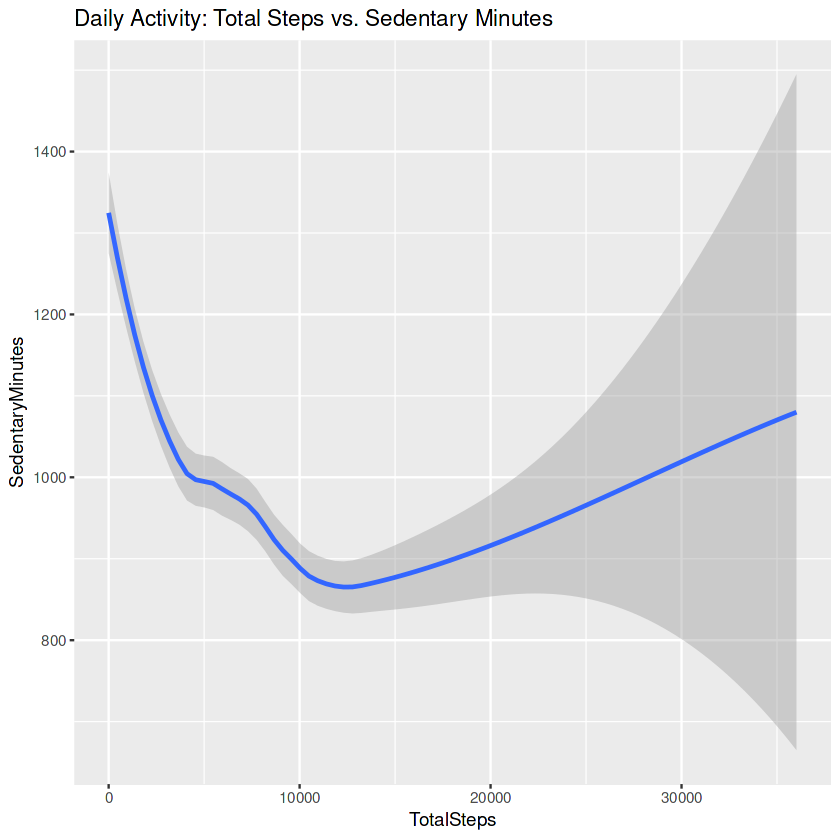

In [8]:
ggplot(data = activity) +
  geom_smooth(mapping =aes(x = TotalSteps, y = SedentaryMinutes)) +
  labs(title = "Daily Activity: Total Steps vs. Sedentary Minutes")

No clear pattern in the plot above.

# Relationship between steps taken in a day and calories.

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


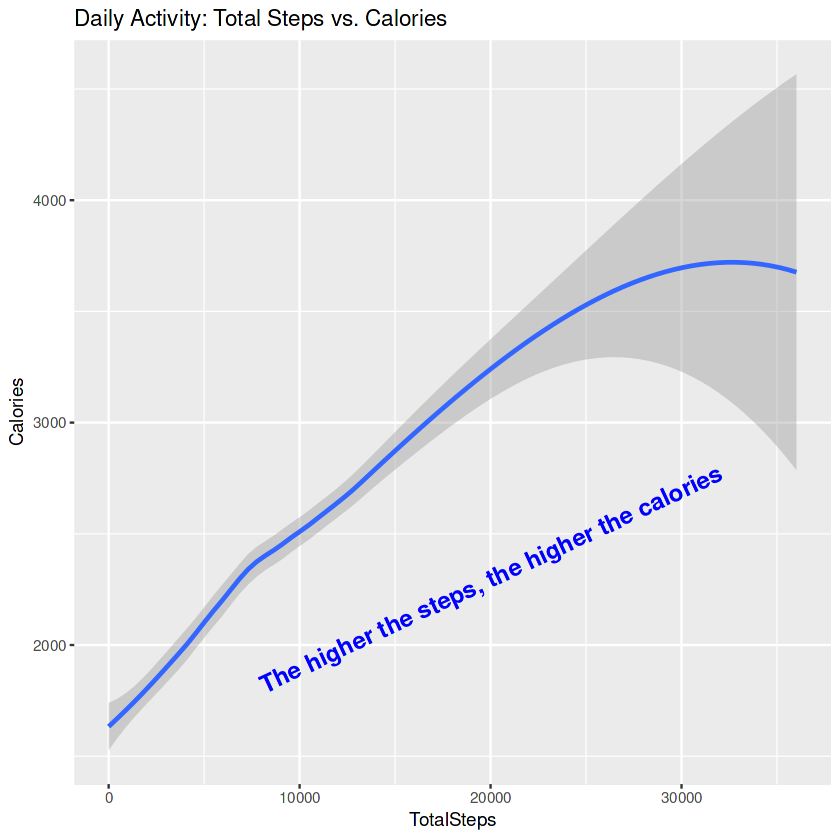

In [9]:
ggplot(data = activity) +
  geom_smooth(mapping = aes(x = TotalSteps, y = Calories)) +
  labs(title = "Daily Activity: Total Steps vs. Calories") +
annotate("text",x =20000, y = 2300, label = "The higher the steps, the higher the calories", color = "blue", fontface = "bold", size = 5, angle = 25)

Positive relationship: as the total steps increased, the calories also increased.

# Relationship between total distance taken in a day and calories

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


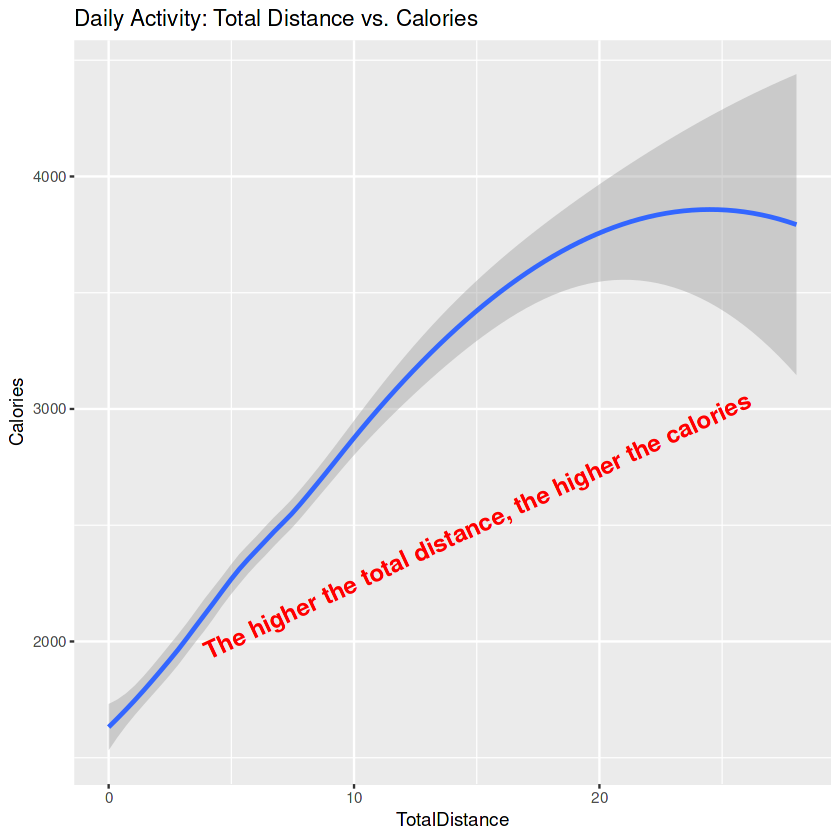

In [10]:
ggplot(data = activity) +
  geom_smooth(mapping = aes(x = TotalDistance, y = Calories)) +
  labs(title = "Daily Activity: Total Distance vs. Calories") +
annotate("text",x = 15, y = 2500, label = "The higher the total distance, the higher the calories", color = "red", fontface = "bold", size = 5, angle = 25)

Positive relationship: as the total distance increased, the calories also increased.

# Relationship between very active minutes and calories

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


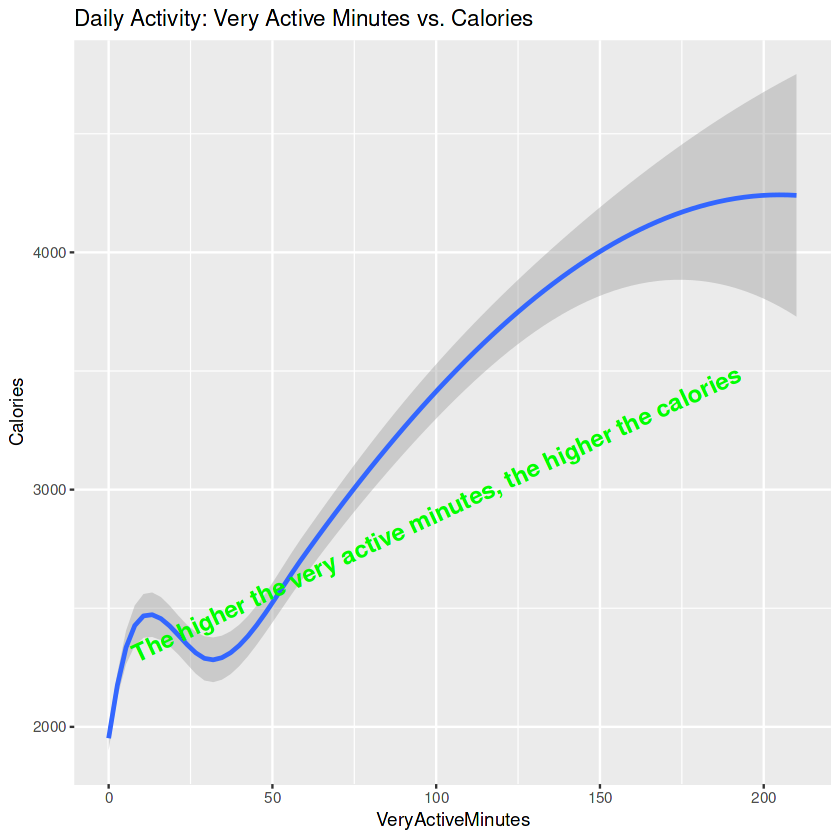

In [11]:
ggplot(data = activity) +
  geom_smooth(mapping = aes(x = VeryActiveMinutes, y = Calories)) +
  labs(title = "Daily Activity: Very Active Minutes vs. Calories") +
annotate("text",x = 100, y = 2900, label = "The higher the very active minutes, the higher the calories", color = "green", fontface = "bold", size = 5, angle = 25)

Positive trend: there is an overall increase in calories as very active minutes increased. The outlier/inconsistency at the beginning of the plot may warrant further investigation.

# Relationship between lightly active minutes and calories


`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


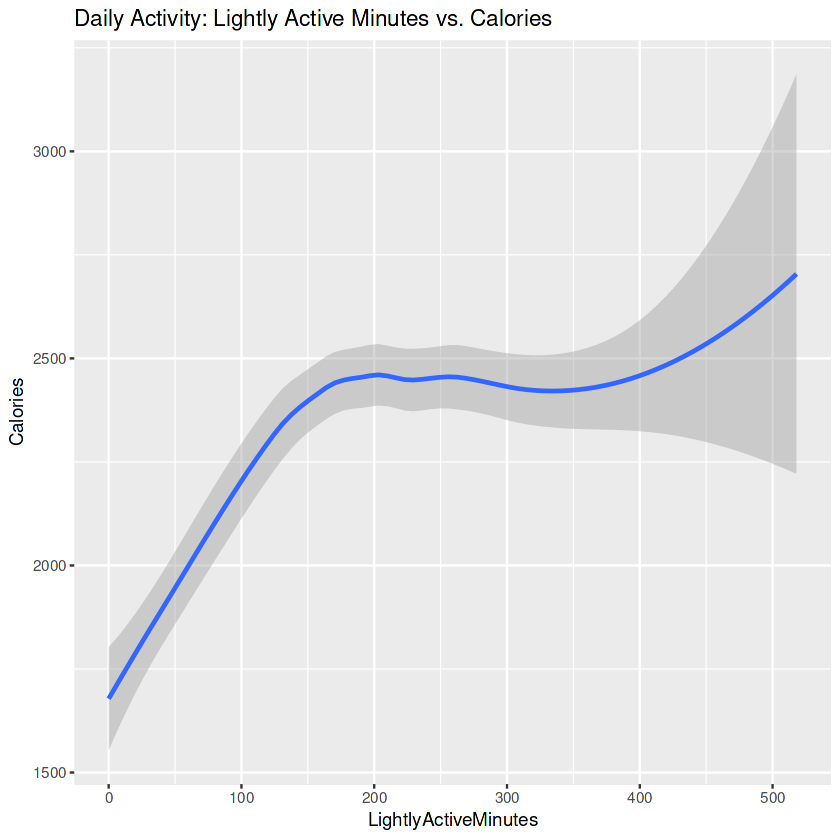

In [12]:
ggplot(data = activity) +
  geom_smooth(mapping = aes(x = LightlyActiveMinutes, y = Calories)) +
  labs(title = "Daily Activity: Lightly Active Minutes vs. Calories") 

No clear pattern here

# Relationship between lightly active minutes and total steps

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


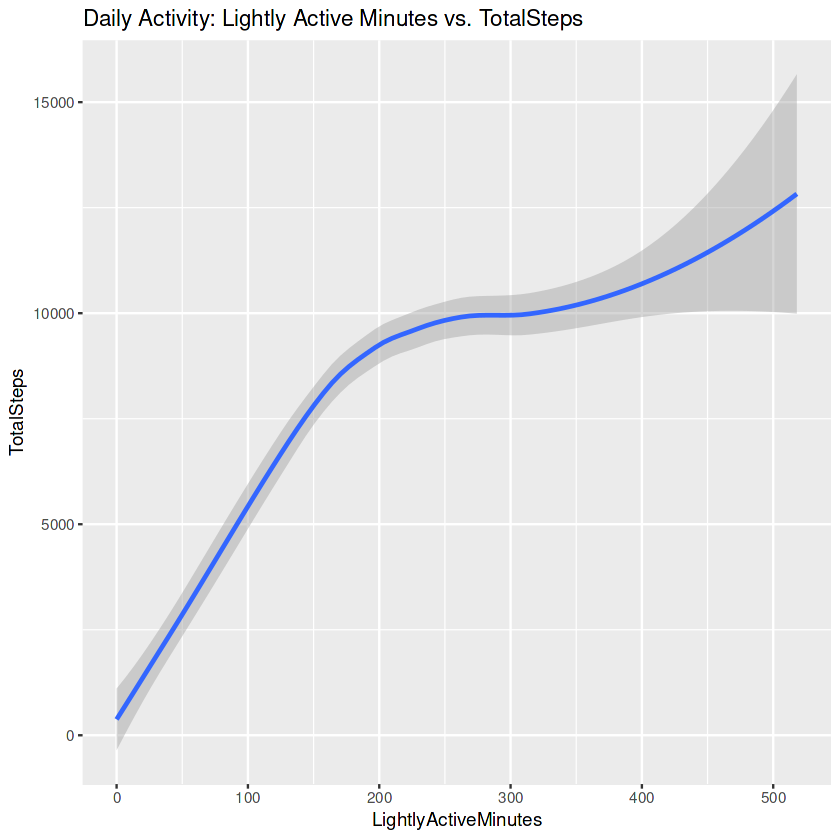

In [13]:
ggplot(data = activity) +
  geom_smooth(mapping = aes(x = LightlyActiveMinutes, y = TotalSteps)) +
  labs(title = "Daily Activity: Lightly Active Minutes vs. TotalSteps") 

No clear pattern here.

# Relationship between sedentary active distance and calories

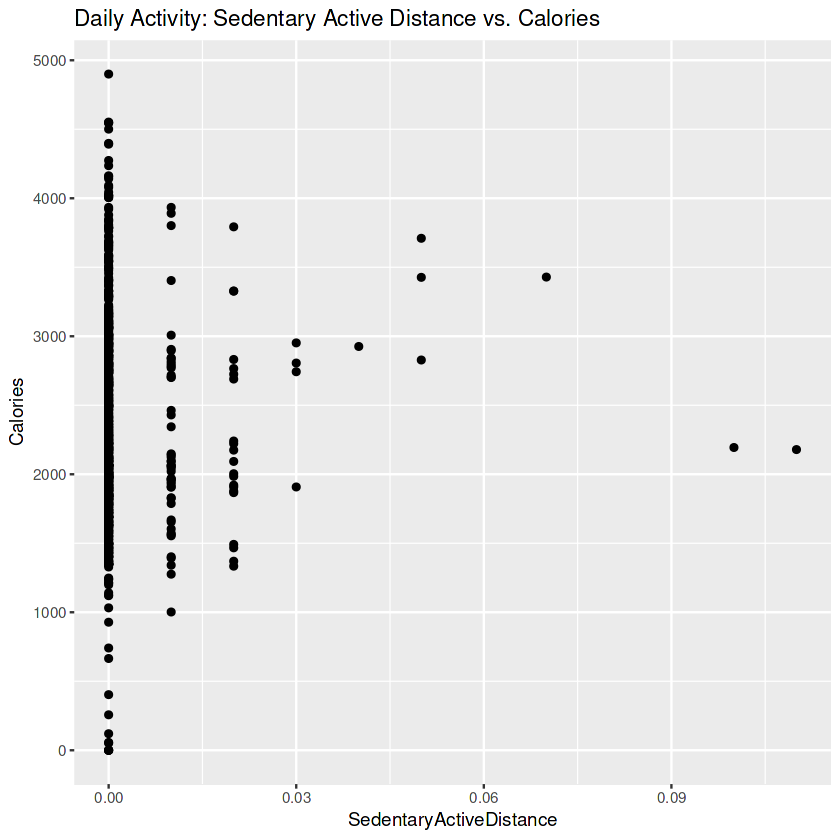

In [14]:
ggplot(data = activity) +
  geom_point(mapping = aes(x = SedentaryActiveDistance, y = Calories)) +
  labs(title = "Daily Activity: Sedentary Active Distance vs. Calories") 

No visible trend here.

# Relationship between light active distance and calories

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


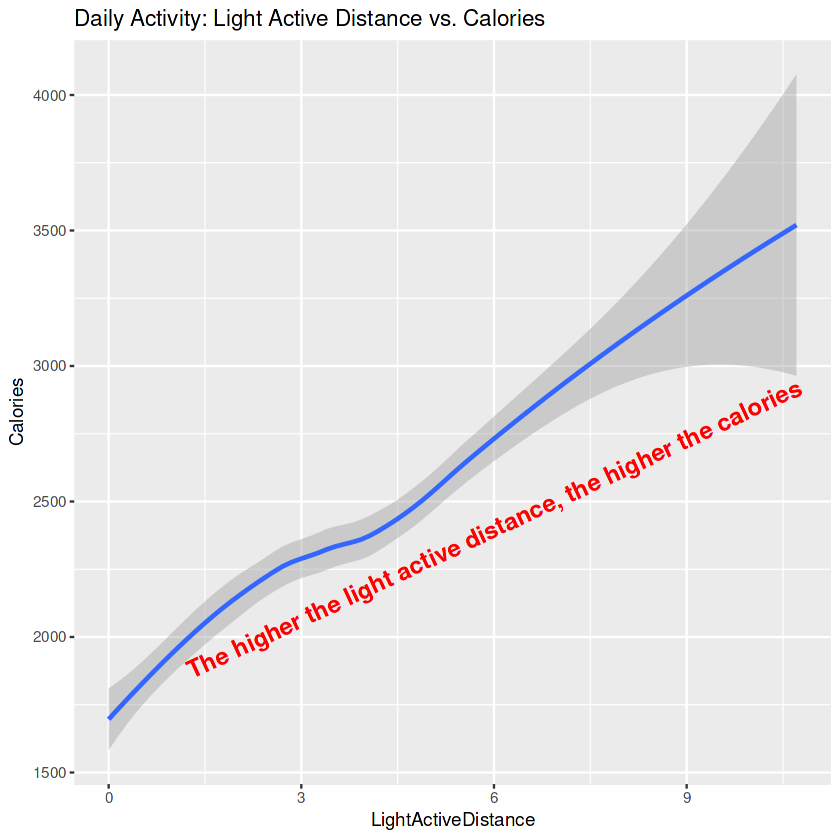

In [15]:
ggplot(data = activity) +
  geom_smooth(mapping = aes(x = LightActiveDistance, y = Calories)) +
  labs(title = "Daily Activity: Light Active Distance vs. Calories") +
annotate("text",x = 6, y = 2400, label = "The higher the light active distance, the higher the calories", color = "red", fontface = "bold", size = 5, angle = 25)

Very positive trend here: as the light active distance increased, the calories also increased.

# Relationship between very active distance and calories

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


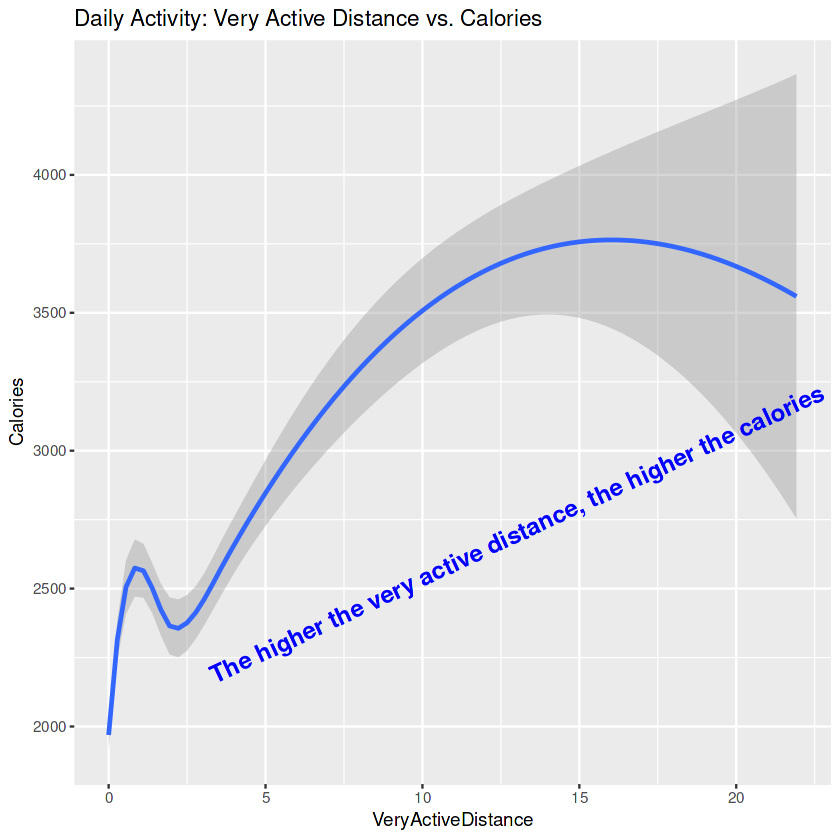

In [16]:
ggplot(data = activity) +
  geom_smooth(mapping = aes(x = VeryActiveDistance, y = Calories)) +
  labs(title = "Daily Activity: Very Active Distance vs. Calories") +
annotate("text",x = 13, y = 2700, label = "The higher the very active distance, the higher the calories", color = "blue", fontface = "bold", size = 5, angle = 25)

Overall positive relationship with outlier at the beginning of the plot that may warrant further investigation. As the very active distance increased, calories also increased.

# Relationship between total minutes asleep and total time in bed

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


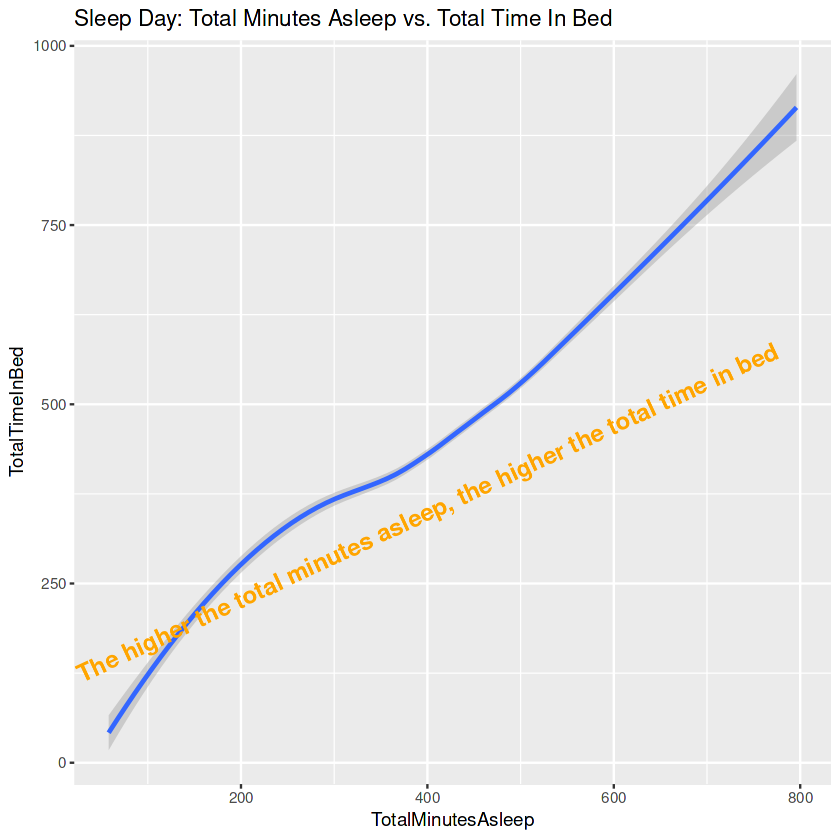

In [17]:
ggplot(data = sleep) +
  geom_smooth(mapping = aes(x = TotalMinutesAsleep, y = TotalTimeInBed)) +
  labs(title = "Sleep Day: Total Minutes Asleep vs. Total Time In Bed") +
annotate("text",x = 400, y = 350, label = "The higher the total minutes asleep, the higher the total time in bed", color = "orange", fontface = "bold", size = 5, angle = 25)

The plot above shows an overall positive relationship: as total minutes asleep increased, so did the total time in bed also increase.


# Relationship between total steps and very active minutes and very active distance

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


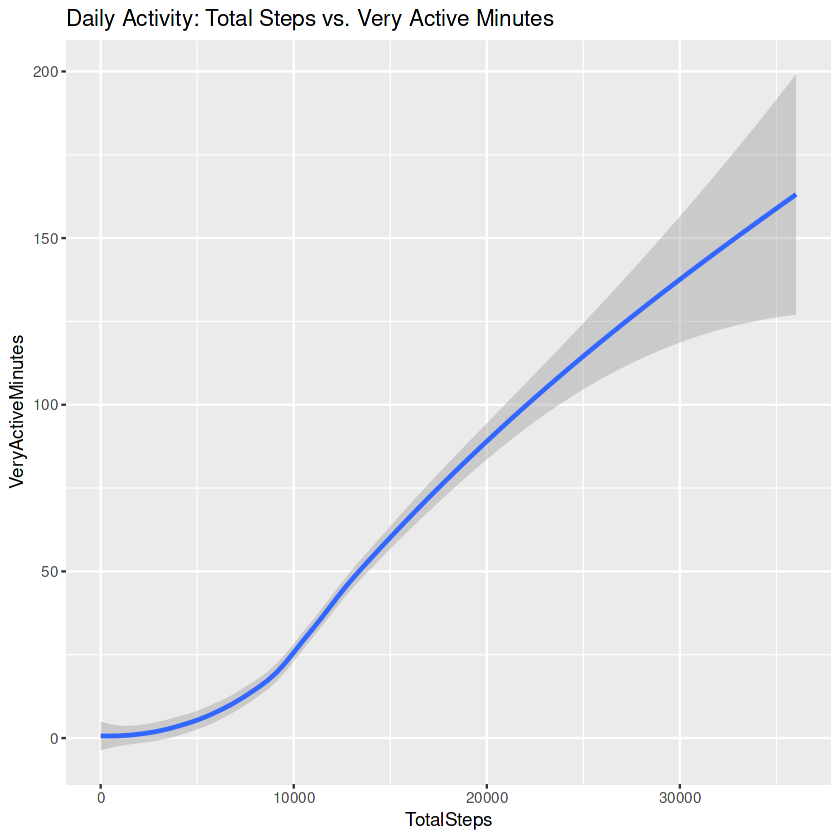

In [18]:
ggplot(data = activity) +
  geom_smooth(mapping =aes(x = TotalSteps, y = VeryActiveMinutes)) +
  labs(title = "Daily Activity: Total Steps vs. Very Active Minutes")

Overall positive relationship

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


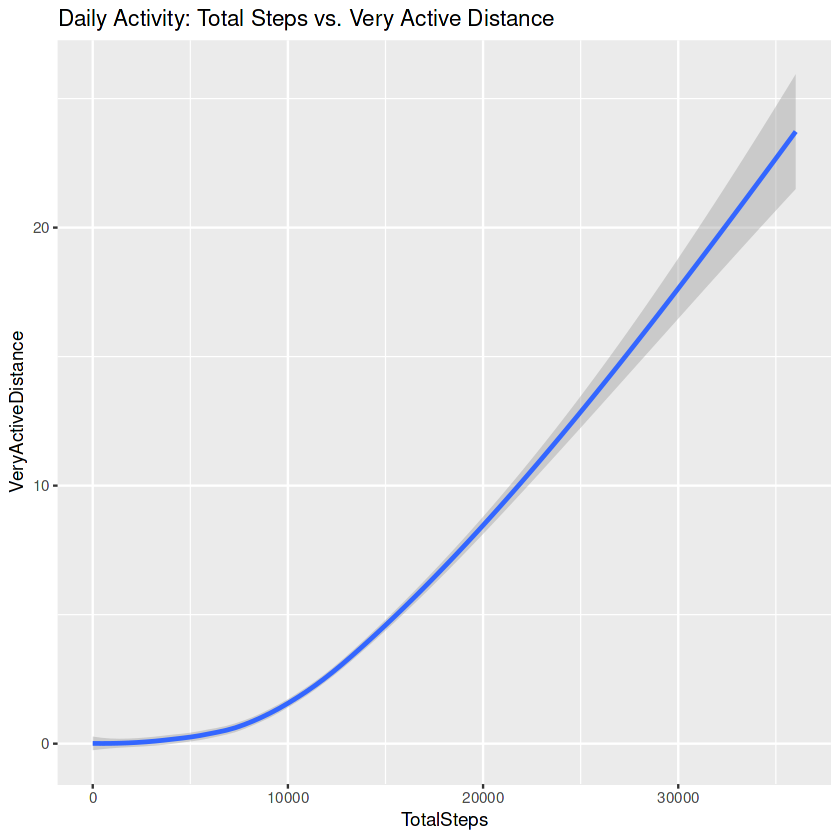

In [19]:
ggplot(data = activity) +
  geom_smooth(mapping =aes(x = TotalSteps, y = VeryActiveDistance)) +
  labs(title = "Daily Activity: Total Steps vs. Very Active Distance")

Overall positive relationship

# Merging Datasets

In [20]:
combined_data <- merge(sleep, activity, by = "Id")

# # Take a look at how many participants are in this dataset

In [21]:
n_distinct(combined_data$Id)

[1] 24

Use full_join to keep filtered out dataset

In [22]:
full_data <- full_join(sleep, activity, by = "Id")

n_distinct(full_data$Id)

Warning message in full_join(sleep, activity, by = "Id"):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 1 of `x` matches multiple rows in `y`.
ℹ Row 1 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”


[1] 33

# Explore Merged Dataset

# Relationship between total minutes asleep and total steps

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


Warning message:
“Removed 227 rows containing non-finite outside the scale range
(`stat_smooth()`).”


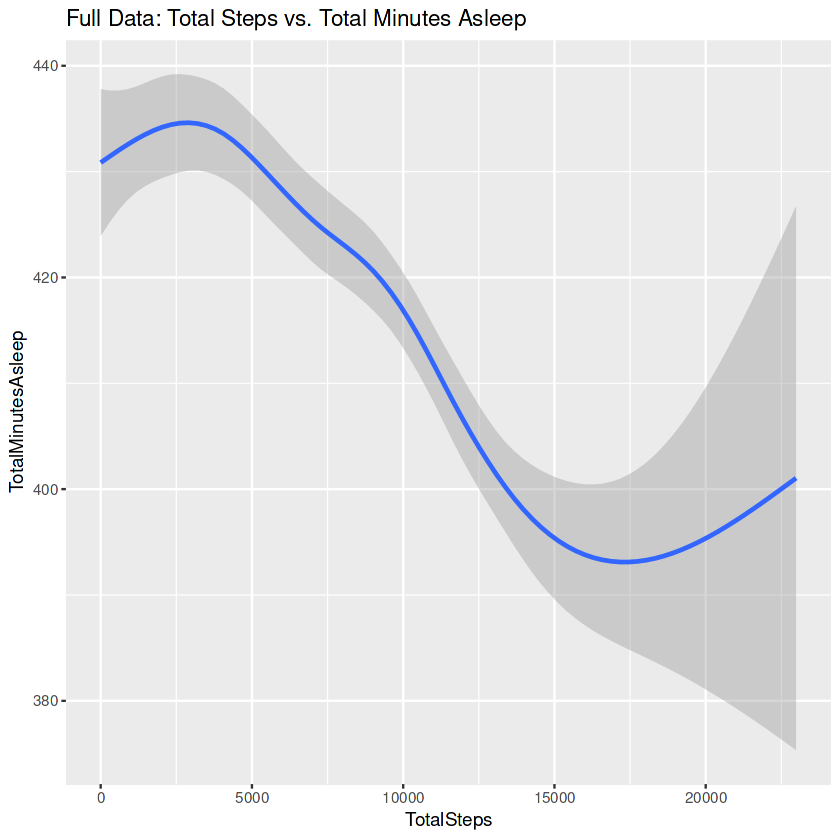

In [23]:
ggplot(data = full_data) +
  geom_smooth(mapping = aes(x = TotalSteps, y = TotalMinutesAsleep)) +
  labs(title = "Full Data: Total Steps vs. Total Minutes Asleep")

This shows an overall negative relationship. As total steps increased, total minutes asleep decreased. There are outliers at the beginning and the end of the plot that may warrant further investigation.

# Relationship between total steps and weight(kg)

In [24]:
full_data1 <- full_join(weight, activity, by = "Id")

n_distinct(full_data1$Id)

Warning message in full_join(weight, activity, by = "Id"):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 1 of `x` matches multiple rows in `y`.
ℹ Row 1 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”


[1] 33

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


Warning message:
“Removed 693 rows containing non-finite outside the scale range
(`stat_smooth()`).”


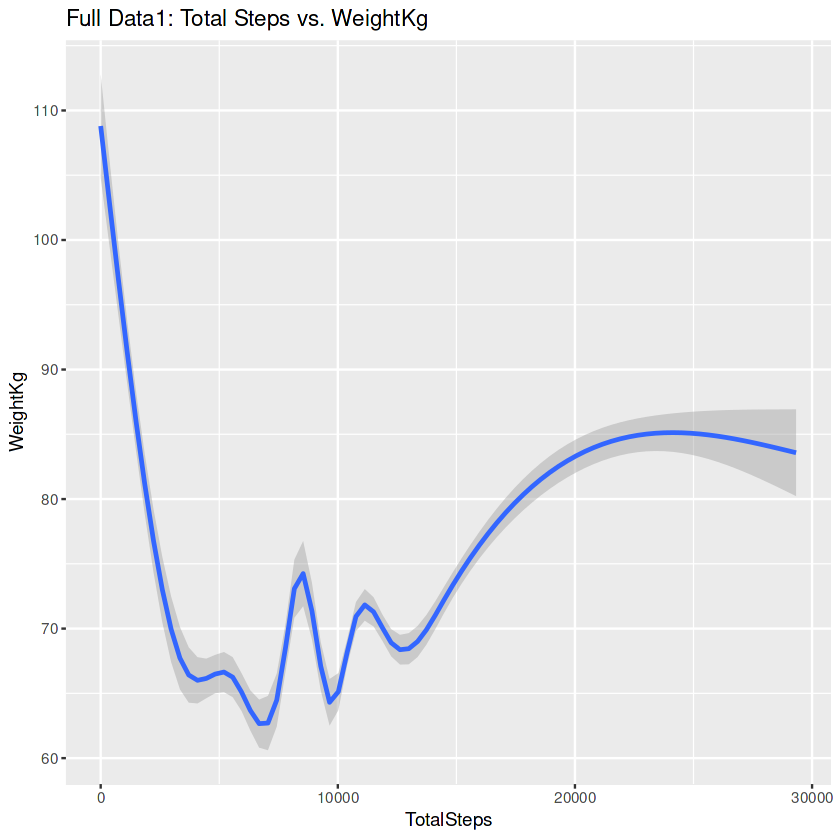

In [25]:
ggplot(data = full_data1) +
  geom_smooth(mapping = aes(x = TotalSteps, y = WeightKg)) +
  labs(title = "Full Data1: Total Steps vs. WeightKg")

The points are scattered randomly with no visible trend. This suggests that the total steps may not be a key driver in determining the weight of the fitbit users.

# Relationship between step total and calories

In [26]:
full_data2 <- full_join(dailyCalories, dailySteps, by = "Id")

n_distinct(full_data2$Id)

Warning message in full_join(dailyCalories, dailySteps, by = "Id"):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 1 of `x` matches multiple rows in `y`.
ℹ Row 1 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”


[1] 33

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


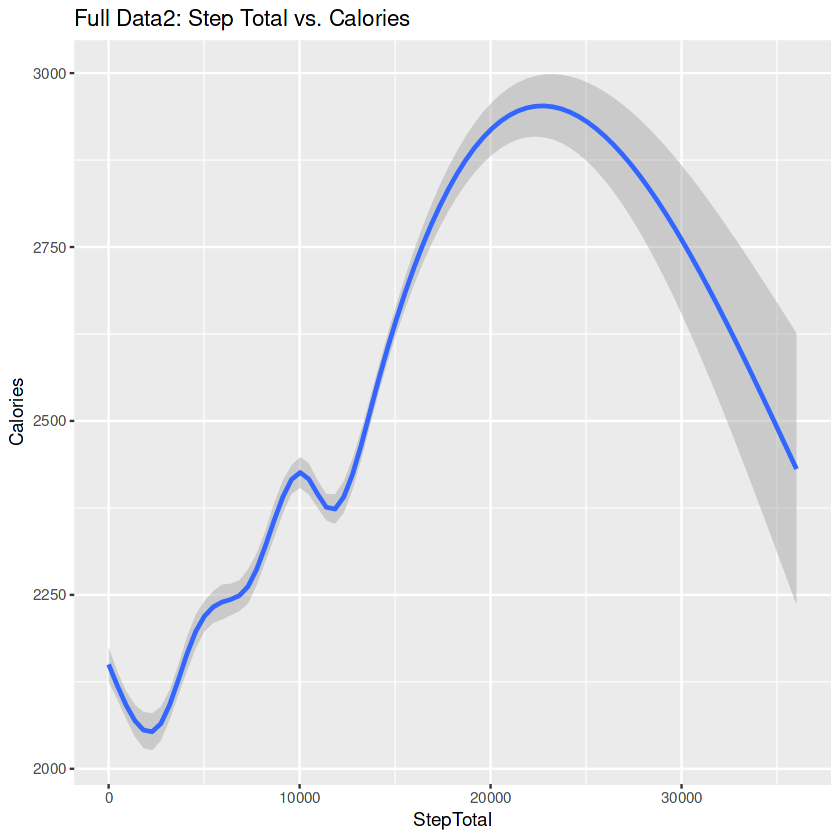

In [27]:
ggplot(data = full_data2) +
  geom_smooth(mapping = aes(x = StepTotal, y = Calories)) +
  labs(title = "Full Data2: Step Total vs. Calories")

This shows no clear relationship.

# Relationship between average total intensity and time

Warning message in geom_histogram(mapping = aes(x = time, y = TotalIntensity), stat = "identity", :
“Ignoring unknown parameters: `binwidth`, `bins`, and `pad`”


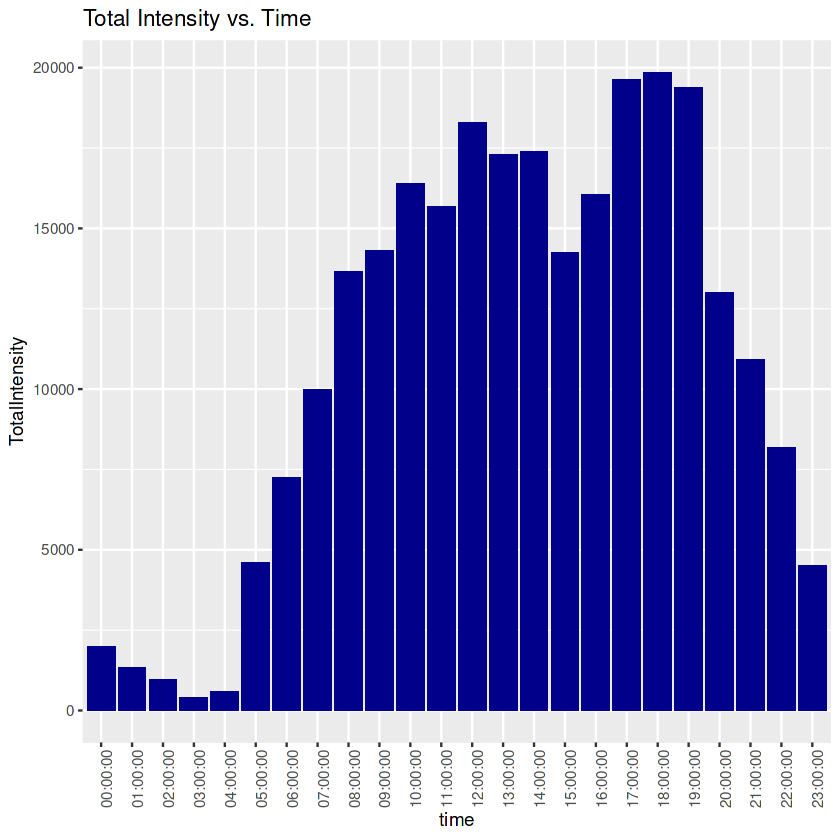

In [28]:

ggplot(data = hourlyIntensities) +
  geom_histogram(mapping = aes(x = time, y = TotalIntensity),stat = "identity", fill ="darkblue") +
  theme(axis.text.x = element_text(angle = 90)) +
  labs(title = "Total Intensity vs. Time")

From this plot, 5pm, 6pm and 7pm had the highest and most consistent total intensities in the day.

# Recommendations

**Note** The data provided did not give information on gender so this is a generalized recommendation limited by the data and sample size provided. Further investigation can still be carried out with the provision of more relevant data.

Overall, increasing distance, steps(activities, stress) and active minutes increases calories and increasing steps taken decreases minutes asleep. 

To optimise women's health specifically in the areas of stress, sleep and activity using the Bellabeat tracker connected to the Bellabeat app, I recommend:

1. **Using Personalised emails and notifications** in the Bellabeat app for users and also recommendations with their health benefits via websites and other marketing media such as social media posts or ads for new or returning visitors. These emails and notifications should include reminders, habits observation, encouragement and healthier habits suggestions. For instance:
   * The average total minutes asleep should be increased from 7 hours daily to 7.5 - 8.5 hours as the standard by reducing sedentary minutes as much as possible and increasing total time in bed by about 1 hour for more sleep time.
   * The average steps per day should be increased from 7638 to about 8763 as the standard by increasing light active minutes into the users schedule or a general realistic schedule for new visitors on the website or social media pages such as daily movements like brisk walks several times a day.
   * The average calories released should be reduced from 2304 to 1900 - 2200kcal/day by reducing the very active minutes daily.

2. More reminders or notifications should be sent to the users on the Bellabeat app from between **5pm and** **7pm** to engage in very active steps such as running because it has been observed to have the highest and most consistent intensities in a day. Lesser hours engaged in very active minutes or steps reduces the average calories released.

3. Notifications **between 10am to 2pm** should also be sent for lighter steps such as strolling as these period had the second largest intensities. This increases daily steps.

4. Notifications or reminders for bed time should also be sent from **10pm lasting till 6pm** for optimal 8 hrs sleep in women per day as these are the times observed to have the lowest intensities in a day. 

Balancing calorie released by reducing steps taken which translates to reduced activity and stress levels leaves enough time for sleep and also help to promote optimum health in women through the app as there will not be too much or too little calories released.

I recommend that these should be incorporated into the next marketing strategy by the Chief Creative Officer of the Bellabeat Company (Urska Srsen).

Thank you for your time.